In [2]:
import numpy as np
import matplotlib.pyplot as plt
from picoparser import PicoParser
from tqdm import tqdm
from pathlib import Path
import pandas as pd

def extract_csi_parallely(
    csi_path: Path,
    ts_start: int,
    ts_end: int,
    tx_idx: int   = 0,
    rx_idx: int   = 0,
    csi_idx: int  = 0,
    min_len: int  = 998,
    num_workers: int = 4,
):
    """Parse a .csi file and return (ts_arr [ns, int64], csi_arr [complex64], bw_arr [int])."""
    with PicoParser(csi_path, num_workers) as parser:
        i = 0
        ts_list, csi_list, bw_list = [], [], []

        for fr in parser.getFrames():
            try:
                ts  = fr.rxSBasic.systemTime
                csi = fr.csi.csi
                csi = np.array([sub_csi[tx_idx][rx_idx][csi_idx] for sub_csi in csi])
                bw = fr.csi.cbw
            except Exception:
                continue

            if ts is None:
                continue
            if (int(ts) < int(ts_start)):
                continue
            if (int(ts) > int(ts)):
                break
            if csi.ndim == 0:
                continue
            if csi.shape[0] < min_len:
                continue

            ts_list.append(int(ts))
            csi_list.append(csi[:min_len])
            bw_list.append(bw)

            # if (i + 1) % 1000 == 0:
            #     print(f"    ...parsed {i + 1} frames")
            i += 1

        print(f"    {i} frames parsed in total")
        return np.array(ts_list, dtype=np.int64), np.array(csi_list), np.array(bw_list)

In [ ]:
# ts_arr, csi_arr, bw_arr = extract_csi_pAlso we shifted focus to arallely(Path('/home/drone/BTP/data_collected/drone/8/rx_2_260422_010313.csi'), 1776799998024000000, 1776800083024000000, num_workers=4)
ts_arr, csi_arr, bw_arr = extract_csi_parallely(Path('/home/drone/BTP/data_collected/lohith/9/rx_2_260424_002320.csi'), 1776970404412000000, 1776970489412000000, num_workers=4)

# Analysing useful subcarriers

(40670, 998)


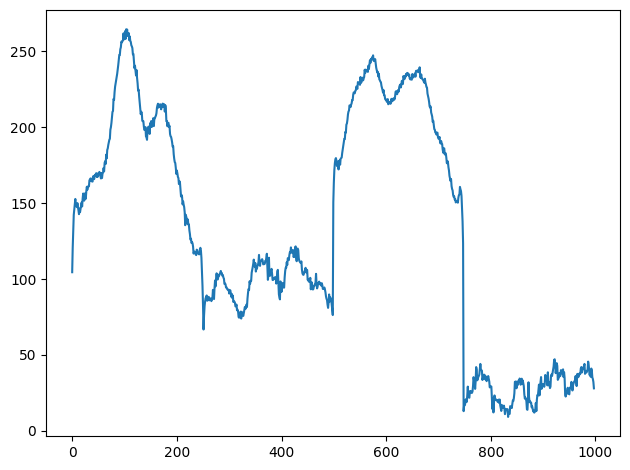

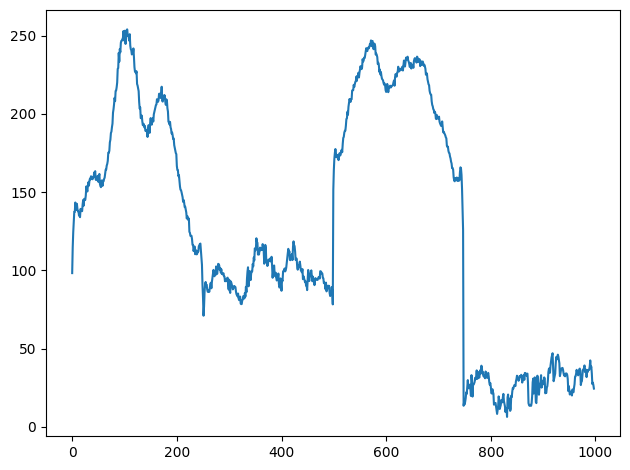

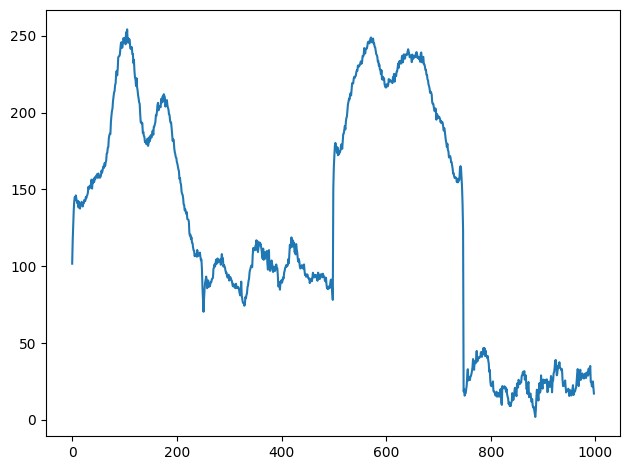

In [2]:
amp_matrix = np.abs(csi_arr)

def visualize_as_spec (matrix_2d):
    plt.figure()
    plt.imshow(
        matrix_2d,
        aspect='auto',
        origin='lower',
        # extent=[0, F],
        cmap='jet'
    )
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def visualize_as_line (arr):
    plt.figure()
    plt.plot(arr)
    plt.tight_layout()
    plt.show()

print(amp_matrix.shape)

amp_freq = amp_matrix[100]
visualize_as_line(amp_freq)
amp_freq = amp_matrix[1000]
visualize_as_line(amp_freq)
amp_freq = amp_matrix[7000]
visualize_as_line(amp_freq)

## Highest variance band

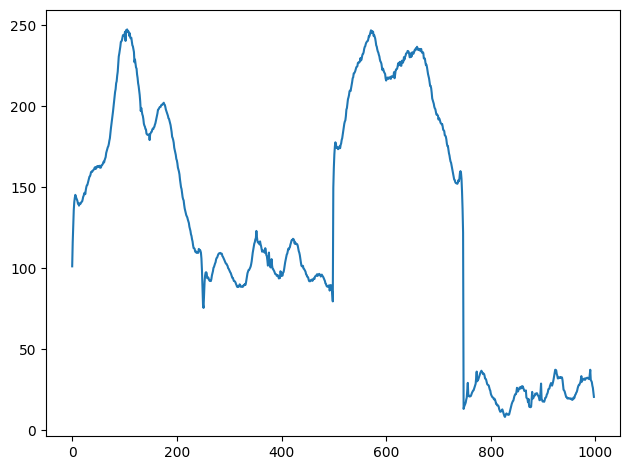

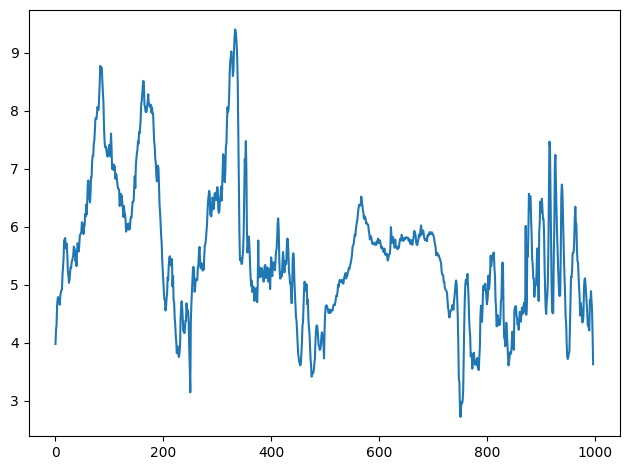

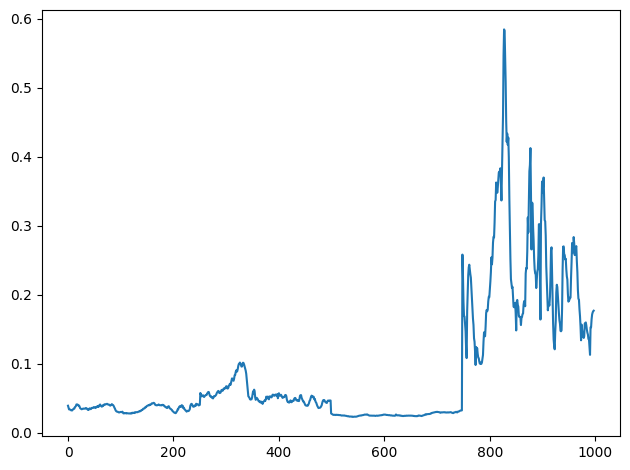

In [12]:
amp_mean = np.mean(amp_matrix, axis=0)
amp_std = np.std(amp_matrix, axis=0)
visualize_as_line(amp_mean)
visualize_as_line(amp_std)
score = amp_std / amp_mean
visualize_as_line(score)

## ANOVA analysis

In [4]:
""" data points accumulation
"""

DIR = Path("data_raw_csi")

# Activity labels
activity_labels = {
    1: "still", 2: "still", 3: "still", 4: "still", 5: "still",
    6: "flip", 7: "flip", 8: "flip", 9: "flip", 10: "flip",
    11: "flip", 12: "flip", 13: "flip", 14: "flip", 15: "flip",
    16: "flip", 17: "flip", 18: "flip", 19: "flip", 20: "flip",
    21: "still", 22: "still", 23: "still", 24: "still", 25: "still",
    26: "type", 27: "type", 28: "type", 29: "type", 30: "type",
    31: "type", 32: "type", 33: "type", 34: "type", 35: "type",
    36: "still", 37: "still", 38: "still", 39: "still", 40: "still",
    41: "flip", 42: "flip", 43: "flip", 44: "flip", 45: "flip",
    46: "flip", 47: "flip", 48: "flip", 49: "flip", 50: "flip",
    51: "flip", 52: "flip", 53: "flip", 54: "flip", 55: "flip",
    56: "still", 57: "still", 58: "still", 59: "still", 60: "still",
    61: "type", 62: "type", 63: "type", 64: "type", 65: "type",
    66: "type", 67: "type", 68: "type", 69: "type", 70: "type",
    71: "still", 72: "still", 73: "still", 74: "still", 75: "still",
    76: "flip", 77: "flip", 78: "flip", 79: "flip", 80: "flip",
    81: "flip", 82: "flip", 83: "flip", 84: "flip", 85: "flip"
}


def accumulate_data_points(dir: Path):

    rows = []

    for file in dir.rglob("*.npz"):

        data_ = np.load(file, allow_pickle=True)

        csi = data_["csi"]
        amp = np.abs(csi)

        ts = data_["ts"]
        relative_ts = (ts - ts[0]) / 1_000_000_000

        # Convert to 2D if needed
        amp_matrix = np.asarray(amp)

        # Extract metadata from filename
        person = file.parent.name          # person1
        test_num = int(file.stem)              # test   

        # 2-second windows
        for start_sec in range(1, 85, 2):

            end_sec = start_sec + 2

            mask = (
                (relative_ts >= start_sec)
                & (relative_ts < end_sec)
            )

            section = amp_matrix[mask]

            if len(section) == 0:
                continue

            mean_vals = np.mean(section, axis=0)
            std_vals = np.std(section, axis=0)

            activity = activity_labels[start_sec]
            if activity_labels[start_sec + 1] != activity :
                continue

            if activity == 'flip' and test_num <= 5:
                activity = 'scroll'

            row = {
                "person": person,
                "test_num": test_num,
                "activity": activity,
                "start_sec": start_sec,
                "end_sec": end_sec
            }

            # Add per-subcarrier stats
            for i in range(len(mean_vals)):
                row[f"sc_{i}_mean"] = mean_vals[i]
                row[f"sc_{i}_std"] = std_vals[i]

            rows.append(row)

        print(f"Processed {file}")

    return pd.DataFrame(rows)


stats_df = accumulate_data_points(DIR)

print(stats_df)

Processed data_raw_csi/daksh/2.npz
Processed data_raw_csi/daksh/4.npz
Processed data_raw_csi/daksh/10.npz
Processed data_raw_csi/daksh/6.npz
Processed data_raw_csi/daksh/9.npz
Processed data_raw_csi/daksh/5.npz
Processed data_raw_csi/daksh/7.npz
Processed data_raw_csi/daksh/1.npz
Processed data_raw_csi/daksh/3.npz
Processed data_raw_csi/daksh/8.npz
Processed data_raw_csi/roshan/2.npz
Processed data_raw_csi/roshan/4.npz
Processed data_raw_csi/roshan/10.npz
Processed data_raw_csi/roshan/6.npz
Processed data_raw_csi/roshan/9.npz
Processed data_raw_csi/roshan/5.npz
Processed data_raw_csi/roshan/7.npz
Processed data_raw_csi/roshan/1.npz
Processed data_raw_csi/roshan/3.npz
Processed data_raw_csi/roshan/8.npz
Processed data_raw_csi/harshith/2.npz
Processed data_raw_csi/harshith/4.npz
Processed data_raw_csi/harshith/10.npz
Processed data_raw_csi/harshith/6.npz
Processed data_raw_csi/harshith/9.npz
Processed data_raw_csi/harshith/5.npz
Processed data_raw_csi/harshith/7.npz
Processed data_raw_cs

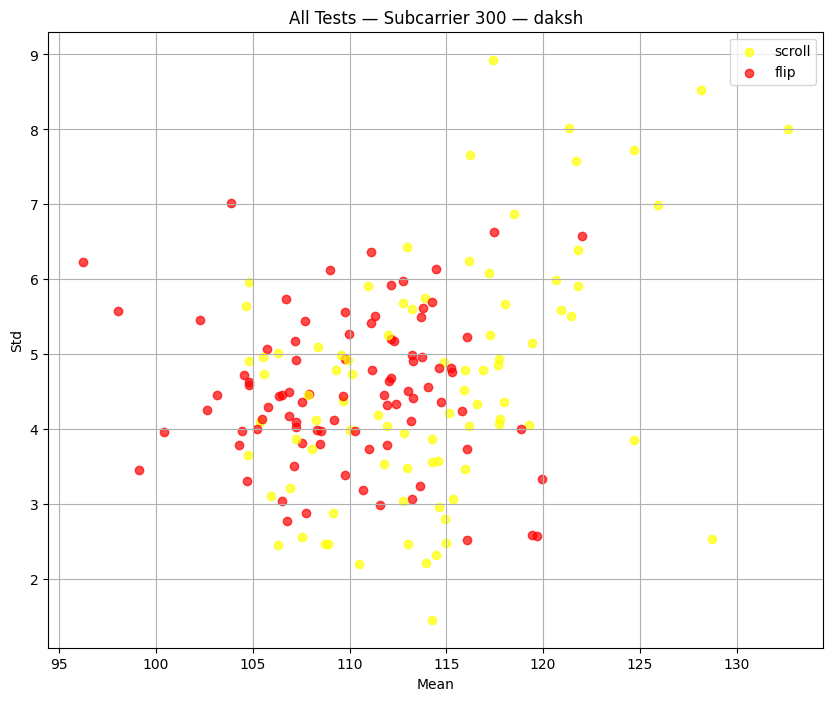

In [5]:
def scatter_points(df: pd.DataFrame, subcarrier_idx: int, person: str|None = None):

    if person is not None:
        stats_df = df[df['person'] == person]
    else:
        stats_df = df

    # Activity colors
    activity_colors = {
        "still": "blue",
        "flip": "red",
        "scroll": "yellow",
        "type": "green"
    }

    # Corresponding column names
    mean_col = f"sc_{subcarrier_idx}_mean"
    std_col = f"sc_{subcarrier_idx}_std"

    plt.figure(figsize=(10, 8))

    # Plot all rows
    for _, row in stats_df.iterrows():

        activity = row["activity"]

        if activity == 'type' or activity == 'still':
            continue

        plt.scatter(
            row[mean_col],
            row[std_col],
            color=activity_colors[activity],
            alpha=0.7,
            label=activity
        )

    # Remove duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))

    plt.legend(unique.values(), unique.keys())

    plt.xlabel("Mean")
    plt.ylabel("Std")
    plt.title(f"All Tests — Subcarrier {subcarrier_idx}")
    if person is not None:
        plt.title(f"All Tests — Subcarrier {subcarrier_idx} — {person}")
    plt.grid(True)

    plt.show()

scatter_points(stats_df, 300, 'daksh')

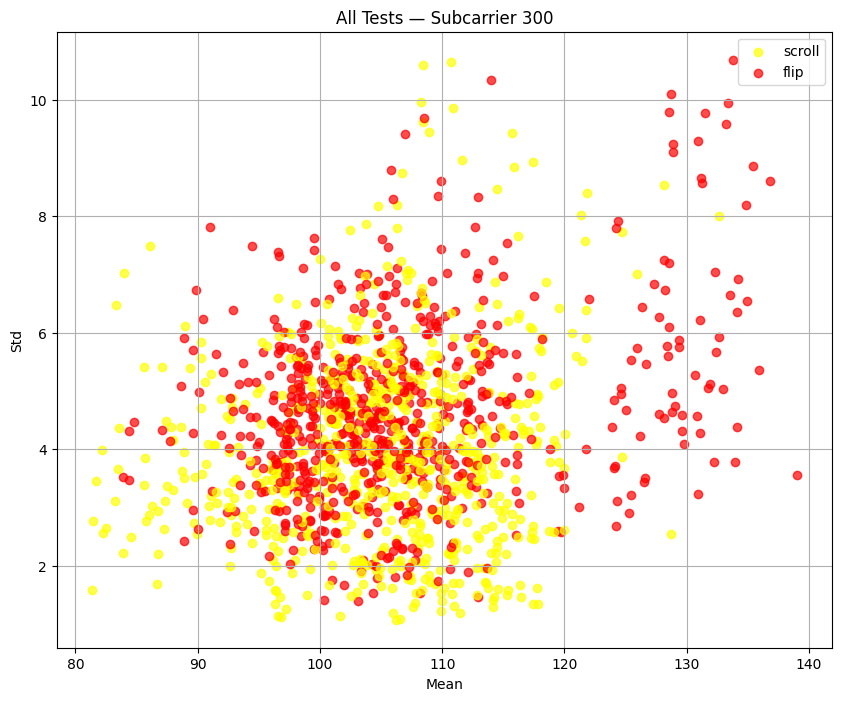

In [6]:
scatter_points(stats_df, 300)

Frontier Accuracy: 0.64


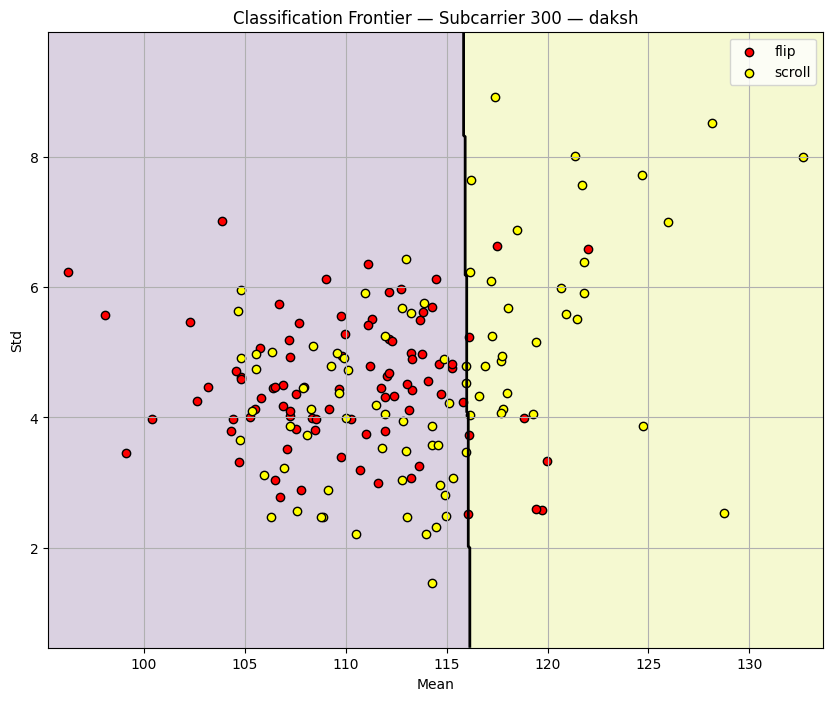

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def scatter_points_with_classification_frontier(df: pd.DataFrame, subcarrier_idx: int, person: str|None = None):

    mean_col = f"sc_{subcarrier_idx}_mean"
    std_col = f"sc_{subcarrier_idx}_std"

    # Keep only flip + scroll
    filtered_df = df[
        df["activity"].isin(["flip", "scroll"])
    ]
    if person is not None:
        filtered_df = filtered_df[filtered_df['person'] == person]

    # Features
    X = filtered_df[[mean_col, std_col]].to_numpy()

    # Labels
    y = filtered_df["activity"].to_numpy()

    # Train nonlinear SVM
    clf = SVC(kernel="rbf", gamma="scale")
    clf.fit(X, y)

    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"Frontier Accuracy: {acc}")

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    # Predict on mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Convert labels to ints for plotting
    Z_num = np.where(Z == "flip", 0, 1)
    Z_num = Z_num.reshape(xx.shape)

    plt.figure(figsize=(10, 8))

    # Draw nonlinear classification regions
    plt.contourf(
        xx,
        yy,
        Z_num,
        alpha=0.2
    )

    # Plot points
    activity_colors = {
        "flip": "red",
        "scroll": "yellow"
    }

    for activity in ["flip", "scroll"]:

        mask = filtered_df["activity"] == activity

        plt.scatter(
            filtered_df.loc[mask, mean_col],
            filtered_df.loc[mask, std_col],
            c=activity_colors[activity],
            label=activity,
            edgecolors="black"
        )

    # Draw decision boundary explicitly
    plt.contour(
        xx,
        yy,
        Z_num,
        levels=[0.5],
        linewidths=2,
        colors="black"
    )

    plt.xlabel("Mean")
    plt.ylabel("Std")
    plt.title(f"Classification Frontier — Subcarrier {subcarrier_idx}")
    if person is not None:
        plt.title(f"Classification Frontier — Subcarrier {subcarrier_idx} — {person}")

    plt.legend()
    plt.grid(True)

    plt.show()


scatter_points_with_classification_frontier(stats_df, 300, 'daksh')
# scatter_points(stats_df, 300, 'drone')
# scatter_points(stats_df, 300, 'harsh')
# scatter_points(stats_df, 300, 'aasritha')
# scatter_points(stats_df, 300, 'harshith')
# scatter_points(stats_df, 300, 'lohith')
# scatter_points(stats_df, 300, 'mihir')
# scatter_points(stats_df, 300, 'roshan')

Frontier Accuracy: 0.5311381531853973


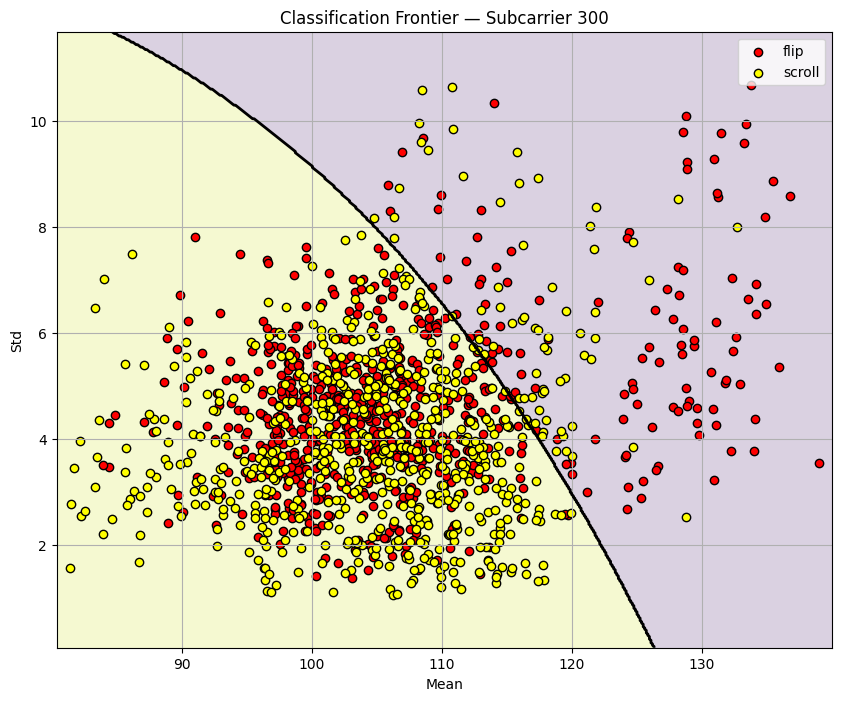

In [9]:
scatter_points_with_classification_frontier(stats_df, 300)

# Models

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

def filter_df(df: pd.DataFrame, activites: list[str]):
    filtered_df = df[
        df["activity"].isin(activites)
    ].copy()
    return filtered_df

def get_train_test_split (df, feature_cols):
    X = df[feature_cols].to_numpy()
    y = df["activity"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    return X_train, X_test, y_train, y_test


def train_model(stats_df):

    # Keep only desired activities
    filtered_df = filter_df(stats_df, ["flip", "scroll"])

    # Collect feature columns
    feature_cols = [
        c for c in filtered_df.columns
        if c.startswith("sc_")
    ]
    
    # Train/test split
    X_train, X_test, y_train, y_test = get_train_test_split(filtered_df, feature_cols)

    # Train classifier
    clf = SVC(
        kernel="rbf",
        gamma="scale"
    )

    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {acc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

train_model(stats_df)

Test Accuracy: 0.5571

Classification Report:

              precision    recall  f1-score   support

        flip       0.56      0.60      0.58       141
      scroll       0.56      0.52      0.54       139

    accuracy                           0.56       280
   macro avg       0.56      0.56      0.56       280
weighted avg       0.56      0.56      0.56       280



Frontier Accuracy: 0.6206156048675734


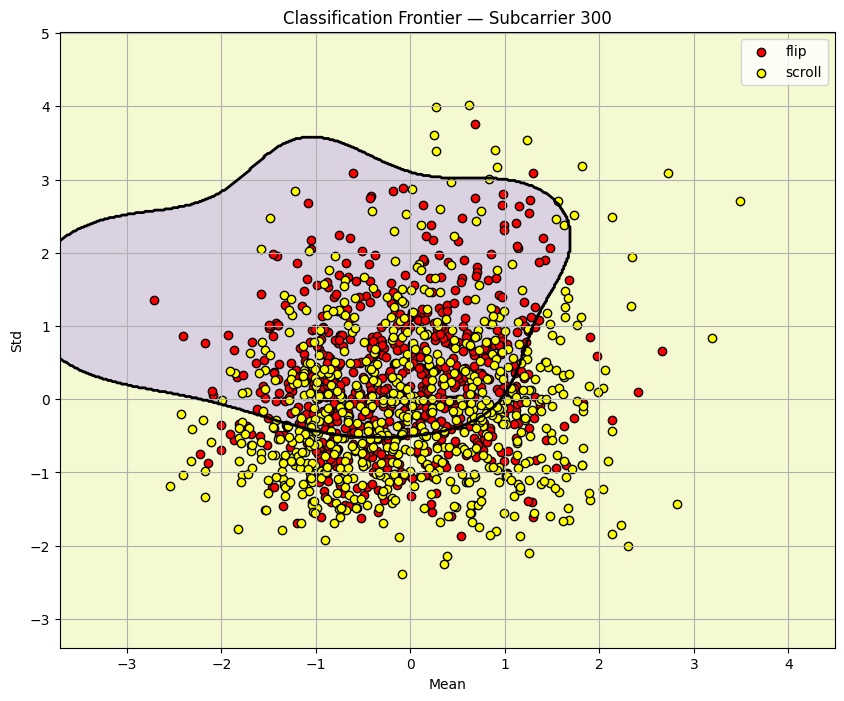

In [ ]:
# Normalize person wise

from sklearn.preprocessing import StandardScaler

def scale_person_wise(stats_df: pd.DataFrame):

    scaled_df = stats_df.copy()

    # Feature columns
    feature_cols = [
        c for c in scaled_df.columns
        if c.startswith("sc_")
    ]

    # Scale person-wise
    for person_id in scaled_df["person"].unique():

        mask = scaled_df["person"] == person_id

        scaler = StandardScaler()

        scaled_df.loc[mask, feature_cols] = scaler.fit_transform(
            scaled_df.loc[mask, feature_cols]
        )
    
    return scaled_df

scaled_data = scale_person_wise(stats_df)

scatter_points_with_classification_frontier(scaled_data, 300)

In [ ]:
# Normalize features person wise

def get_train_test_split (df, feature_cols):

    X = df[feature_cols].to_numpy()
    y = df["activity"].to_numpy()

    persons = df["person"].to_numpy()
    (
        X_train,
        X_test,
        y_train,
        y_test,
        person_train,
        person_test
    ) = train_test_split(
        X,
        y,
        persons,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train_scaled = np.zeros_like(X_train, dtype=float)
    X_test_scaled = np.zeros_like(X_test, dtype=float)

    # Store scalers here
    person_scalers = {}

    # Fit scaler on each person's TRAIN data
    for person_id in np.unique(person_train):

        train_mask = person_train == person_id

        scaler = StandardScaler()

        X_train_scaled[train_mask] = scaler.fit_transform(
            X_train[train_mask]
        )

        person_scalers[person_id] = scaler

    # Transform TEST data using stored scalers
    for person_id in np.unique(person_test):

        test_mask = person_test == person_id

        # Skip unseen persons
        if person_id not in person_scalers:
            continue

        scaler = person_scalers[person_id]

        X_test_scaled[test_mask] = scaler.transform(
            X_test[test_mask]
        )
    
    return X_train_scaled, X_test_scaled, y_train, y_test

train_model(stats_df)

Test Accuracy: 0.9786

Classification Report:

              precision    recall  f1-score   support

        flip       0.99      0.97      0.98       141
      scroll       0.97      0.99      0.98       139

    accuracy                           0.98       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.98      0.98       280

